# WIP: Germany New Passenger Vehicle Registrations Plots

In Germany, the Kraftfahrtbundesamt (KBA) publishes monthly numbers on passenger vehicle registrations by segment in their FZ 8 publication:

Neuzulassungen von Kraftfahrzeugen und Kraftfahrzeuganhängern  
https://www.kba.de/DE/Statistik/Produktkatalog/produkte/Fahrzeuge/fz8/fz8_gentab.html

I noticed that they provide data by car segment, so I wanted to see EV uptake here plotted.  
The plots should be updated automatically once new data is released if everything works :)

### Related links and dashboards

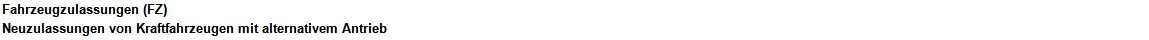

In [1]:
import copy

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

%load_ext autoreload
%autoreload 2

import de_kba_datagrabber as kba
from adac_aggregate import get_aggregated_adac_price_data
from utils import PowerType
from plot_utils import draw_pie

In [2]:
kba.ensure_up_to_date()
ev_data_raw = kba.fz8_3_models_get()
adac_price_data = get_aggregated_adac_price_data()

August 2025


In [3]:
# Group everything under ICE; Other now only is Hydrogen pretty much
ev_data = ev_data_raw.copy()
ev_data[PowerType.ICE] = ev_data[PowerType.ICE_P] + ev_data[PowerType.ICE_D] + ev_data[PowerType.HEV] + ev_data[PowerType.CNG] + ev_data[PowerType.LPG]
#ev_data[PowerType.Gas] = ev_data[PowerType.CNG] + ev_data[PowerType.LPG]
#ev_data[PowerType.Other] += 
del ev_data[PowerType.ICE_P]
del ev_data[PowerType.ICE_D]
del ev_data[PowerType.CNG]
del ev_data[PowerType.LPG]
del ev_data[PowerType.HEV]
ev_data.stack()

DACIA SPRING     PHEV       0
                 BEV      315
                 Other      0
                 ICE        0
FIAT 500         PHEV       0
                         ... 
MERCEDES UNIMOG  ICE        1
RENAULT MASTER   PHEV       0
                 BEV        0
                 Other      0
                 ICE       49
Length: 1372, dtype: int64

In [4]:
adac_fuel_map = {
    'Super': PowerType.ICE,
    'Super Plus': PowerType.ICE,
    'Super / Super': PowerType.ICE,
    'Diesel': PowerType.ICE,
    'Super / Strom': PowerType.PHEV,
    'Super Plus / Strom': PowerType.PHEV,
    'Diesel / Strom': PowerType.PHEV,
    'Strom / Super': PowerType.PHEV,
    'Strom / Super Plus': PowerType.PHEV,
    'Flüssiggas': PowerType.ICE,
    'Erdgas / Super': PowerType.ICE,
    'Strom': PowerType.BEV,
    'Wasserstoff': PowerType.Other,
}

# Re-group by mapped fuel types and recalculate min, max, avg

mapped_index = pd.MultiIndex.from_tuples(
    [(name, adac_fuel_map.get(fuel)) for name, fuel in adac_price_data.index],
    names=['NAME', 'fuelType']
)

adac_price_regrouped = adac_price_data.copy()
adac_price_regrouped.index = mapped_index

# Recalculate stats per NAME and new fuelType
adac_price_regrouped = adac_price_regrouped.groupby(level=['NAME', 'fuelType']).agg(
    min_price=('min_price', 'min'),
    max_price=('max_price', 'max'),
    avg_price=('avg_price', 'mean'),
    med_price=('med_price', 'median'),
)

adac_price_regrouped


min_price max_price     avg_price med_price
NAME               fuelType                                            
ALFA ROMEO GIULIA  ICE        56000.0   66500.0  61333.333333   61500.0
ALFA ROMEO JUNIOR  BEV        39500.0   48500.0       43750.0   43500.0
                   ICE        30450.0   40000.0       35480.0   36500.0
ALFA ROMEO STELVIO ICE        60600.0   71100.0  65933.333333   66100.0
ALFA ROMEO TONALE  ICE        40800.0   52800.0  46883.333333   47050.0
...                               ...       ...           ...       ...
VW TRANSPORTER     ICE        43768.0   88995.0  63940.718468   62484.0
                   PHEV       55258.0  102847.0       71282.0   64037.0
XPENG G6           BEV        47600.0   51600.0       49600.0   49600.0
XPENG G9           BEV        59600.0   72600.0  65266.666667   63600.0
XPENG P7           BEV        49600.0   58600.0       54100.0   54100.0

[519 rows x 4 columns]

Now that both datasources have been brought into the same grouping and format, merge them

In [5]:
# For every non-zero entry in ev_data.stack(), add matching price columns from adac_price_regrouped; drop zeros
ev_full_data = ev_data.stack()
ev_full_data = ev_full_data[ev_full_data != 0]

# Ensure MultiIndex aligned with (NAME, fuelType)
ev_full_data.index = pd.MultiIndex.from_tuples(ev_full_data.index, names=['NAME', 'fuelType'])

# Join with price data and drop entries without price info
ev_full_data = ev_full_data.to_frame('registrations').join(adac_price_regrouped, how='left').dropna(
    subset=['min_price', 'max_price', 'avg_price', 'med_price'])

ev_full_data


registrations min_price max_price     avg_price  \
NAME           fuelType                                                    
DACIA SPRING   BEV                 315   16900.0   19900.0       18400.0   
FIAT 500       BEV                 928   24990.0   37990.0  31061.428571   
FIAT PANDA     ICE                  84   18990.0   24990.0  21823.333333   
KIA PICANTO    ICE                 736   17850.0   22550.0       20250.0   
LEAPMOTOR T03  BEV                 606   18900.0   18900.0       18900.0   
...                                ...       ...       ...           ...   
VW ID. BUZZ    BEV                 510   49998.0   75065.0  61397.727273   
VW TRANSPORTER PHEV                423   55258.0  102847.0       71282.0   
               BEV                  24   59310.0   79724.0  68482.522222   
               ICE                1848   43768.0   88995.0  63940.718468   
RENAULT MASTER ICE                  49   41995.0   54014.0  48515.828125   

                        med_price  
NAME           fuelType            
DACIA SPRING   BEV        18400.0  
FIAT 500       BEV        30990.0  
FIAT PANDA     ICE        21490.0  
KIA PICANTO    ICE        20550.0  
LEAPMOTOR T03  BEV        18900.0  
...                           ...  
VW ID. BUZZ    BEV        61077.0  
VW TRANSPORTER PHEV       64037.0  
               BEV        67895.5  
               ICE        62484.0  
RENAULT MASTER ICE        48659.0  

[409 rows x 5 columns]

Looking at the user request, they want to calculate fractions of BEV, ICE, and PHEV within a 10k price range of each entry's average_price and add those as new columns to ev_full_data.



In [6]:
# For every entry in ev_full_data, calculate the fraction of bev, ice and phev within 10k of the average_price
comparison_range_abs = 5000  # price range
comparison_range_factor = 0.1
price_to_use = 'med_price'

# Reset index to work with the data more easily
ev_full_data_w_fractions = ev_full_data.reset_index()

# Initialize the fraction columns
ev_full_data_w_fractions['frac_bev_nearby'] = 0.0
ev_full_data_w_fractions['frac_ice_nearby'] = 0.0
ev_full_data_w_fractions['frac_phev_nearby'] = 0.0
ev_full_data_w_fractions['frac_other_nearby'] = 0.0
ev_full_data_w_fractions['frac_nearby'] = 0.0

# For each entry, calculate fractions within 10k of its average_price
for idx, row in ev_full_data_w_fractions.iterrows():
    target_price = row[price_to_use]
    comp_range = comparison_range_abs + comparison_range_factor * target_price

    # Find all entries within 10k of this price
    price_mask = (ev_full_data_w_fractions[price_to_use] >= target_price - comp_range) & (ev_full_data_w_fractions[price_to_use] <= target_price + comp_range)
    nearby_data = ev_full_data_w_fractions[price_mask]

    # Calculate total registrations for each fuel type within the range
    bev_total = nearby_data[nearby_data['fuelType'] == PowerType.BEV]['registrations'].sum()
    ice_total = nearby_data[nearby_data['fuelType'] == PowerType.ICE]['registrations'].sum()
    phev_total = nearby_data[nearby_data['fuelType'] == PowerType.PHEV]['registrations'].sum()
    other_total = nearby_data[nearby_data['fuelType'] == PowerType.Other]['registrations'].sum()

    # Calculate total registrations within the range
    total_nearby = bev_total + ice_total + phev_total

    # Calculate fractions (avoid division by zero)
    if total_nearby > 0:
        ev_full_data_w_fractions.loc[idx, 'frac_bev_nearby'] = bev_total / total_nearby
        ev_full_data_w_fractions.loc[idx, 'frac_ice_nearby'] = ice_total / total_nearby
        ev_full_data_w_fractions.loc[idx, 'frac_phev_nearby'] = phev_total / total_nearby
        ev_full_data_w_fractions.loc[idx, 'frac_other_nearby'] = other_total / total_nearby
        ev_full_data_w_fractions.loc[idx, 'frac_nearby'] = ev_full_data_w_fractions.loc[idx, f'frac_{row['fuelType'].lower()}_nearby']

# Set the index back and update ev_full_data
ev_full_data_w_fractions.set_index(['NAME', 'fuelType'], inplace=True)

ev_full_data_w_fractions.to_csv('data/de/car_registrations_last_month_with_price_and_fractions.csv')
ev_full_data_w_fractions

registrations min_price max_price     avg_price  \
NAME           fuelType                                                    
DACIA SPRING   BEV                 315   16900.0   19900.0       18400.0   
FIAT 500       BEV                 928   24990.0   37990.0  31061.428571   
FIAT PANDA     ICE                  84   18990.0   24990.0  21823.333333   
KIA PICANTO    ICE                 736   17850.0   22550.0       20250.0   
LEAPMOTOR T03  BEV                 606   18900.0   18900.0       18900.0   
...                                ...       ...       ...           ...   
VW ID. BUZZ    BEV                 510   49998.0   75065.0  61397.727273   
VW TRANSPORTER PHEV                423   55258.0  102847.0       71282.0   
               BEV                  24   59310.0   79724.0  68482.522222   
               ICE                1848   43768.0   88995.0  63940.718468   
RENAULT MASTER ICE                  49   41995.0   54014.0  48515.828125   

                        med_price  frac_bev_nearby  frac_ice_nearby  \
NAME           fuelType                                               
DACIA SPRING   BEV        18400.0         0.091333         0.908667   
FIAT 500       BEV        30990.0         0.108019         0.890059   
FIAT PANDA     ICE        21490.0         0.089195         0.910805   
KIA PICANTO    ICE        20550.0         0.114398         0.885602   
LEAPMOTOR T03  BEV        18900.0         0.067910         0.932090   
...                           ...              ...              ...   
VW ID. BUZZ    BEV        61077.0         0.208307         0.601221   
VW TRANSPORTER PHEV       64037.0         0.193814         0.583832   
               BEV        67895.5         0.150067         0.546689   
               ICE        62484.0         0.220507         0.593092   
RENAULT MASTER ICE        48659.0         0.213002         0.657625   

                         frac_phev_nearby  frac_other_nearby  frac_nearby  
NAME           fuelType                                                    
DACIA SPRING   BEV               0.000000           0.000000     0.091333  
FIAT 500       BEV               0.001922           0.000000     0.108019  
FIAT PANDA     ICE               0.000000           0.000000     0.910805  
KIA PICANTO    ICE               0.000000           0.000000     0.885602  
LEAPMOTOR T03  BEV               0.000000           0.000000     0.067910  
...                                   ...                ...          ...  
VW ID. BUZZ    BEV               0.190472           0.000000     0.208307  
VW TRANSPORTER PHEV              0.222354           0.000045     0.222354  
               BEV               0.303244           0.000058     0.150067  
               ICE               0.186401           0.000000     0.593092  
RENAULT MASTER ICE               0.129373           0.000000     0.657625  

[409 rows x 10 columns]